# Testing kpoint-convergence with Energy 

K-points (or k-vectors) are fundamental to periodic electronic structure calculations of crystalline materials. They are discrete points used to sample the Brillouin zone (BZ), which is the primitive unit cell of the reciprocal lattice containing all unique and physically distinct k-states.

Electronic properties such as the total energy, charge density, and band structure are computed at these selected k-points.

Since the Brillouin zone is continuous, integrals over the BZ are approximated by finite sums over k-points. The density of k-point sampling determines how accurately these sums represent the true integrals. Because all crystal properties are obtained by integrating over the entire Brillouin zone, sufficiently dense k-point sampling is essential for accurate results.

### Why too coarse k-point sampling causes problem?

  1) Error in total and relative energies
  2) Shifts,instabilities and inaccuracies near the fermi-level
  3) Poor Density of states(DOS)

In [24]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX4


In [25]:
%cd /home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX1


In [26]:
ls

C.psml  GC_0/  GC_10/  GC_20/  GC_30/  GC_40/  GC_50/  graphene.fdf  kconv.dat


In [27]:
!mkdir EX1

In [28]:
!cp C.psml graphene.fdf EX1

In [36]:
%cd /home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX1


In [37]:
ls

C.psml  GC_0/  GC_10/  GC_20/  GC_30/  GC_40/  GC_50/  graphene.fdf  kconv.dat


In [38]:
!cat graphene.fdf

# General system specifications ....
SystemName    graphene
SystemLabel   graphene

NumberOfAtoms    2
NumberOfSpecies  1

%block ChemicalSpeciesLabel
    1   6  C
%endblock ChemicalSpeciesLabel

# Structural parameters...
LatticeConstant 2.476675 Ang
%block LatticeParameters
1.000  1.000  10.0  90.0  90.0  120.0
%endblock LatticeParameters

AtomicCoordinatesFormat fractional

%block AtomicCoordinatesAndAtomicSpecies
  0.33333333  0.66666667  0.5        1     # C
  0.66666667  0.33333333  0.5        1     # C
%endblock AtomicCoordinatesAndAtomicSpecies

# Simulation parameters ...
SolutionMethod         diagon

XC.Functional          LDA
XC.Authors             CA
#Spin                   polarized

SCF.Mixer.Weight       0.1
SCF.Mixer.History      3
SCF.DM.Tolerance       5.0d-5

DM.UseSaveDM           T

# Basis set definition...
PAO.BasisSize         DZP
PAO.EnergyShift       10 meV


# Real space grid...
MeshCutoff           140.0 Ry

kgridcutoff 0 bohr


# K-sampling (using Monkhors

In [39]:
%%bash

# Define kgridcutoff values (bash array)
gridcutoff=(0 10 20 30 40 50)

for gc in "${gridcutoff[@]}"; do
    echo "=============================="
    echo "Running kgridcutoff = $gc bohr"

    mkdir -p GC_${gc}
    cp C.psml GC_${gc}/
    cp graphene.fdf GC_${gc}/

    f="GC_${gc}/graphene.fdf"

    # Remove any existing kgridcutoff line
    sed -i '/^[[:space:]]*kgridcutoff/d' "$f"

    # Append new kgridcutoff
    echo "kgridcutoff ${gc} bohr" >> "$f"

    # Run SIESTA
    cd GC_${gc} || exit 1
    siesta < graphene.fdf > graphene.out
    cd ..
done


Running kgridcutoff = 0 bohr


Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed


Running kgridcutoff = 10 bohr


Job completed


Running kgridcutoff = 20 bohr


...

Job completed


Running kgridcutoff = 40 bohr


Job completed


Running kgridcutoff = 50 bohr


Job completed


In [40]:
ls

C.psml  GC_0/  GC_10/  GC_20/  GC_30/  GC_40/  GC_50/  graphene.fdf  kconv.dat


In [41]:
%%bash
#create a data file,named 'kconv.dat'
echo "# kgridcutoff  Nkpoints  keff(Ang)  TotalEnergy(eV)" > kconv.dat
#loop for all directories,named,*means'all'
for d in GC_*; do
    gc=${d#GC_} # extract the kgridcutoff value

    Nk=$(grep "Number of k-points" $d/graphene.out | awk '{print $NF}') #extract nuber of grid point 
    keff=$(grep -i "k-cutoff (effective)" $d/graphene.out | awk '{print $(NF-1)}')  #extract k-cutoff (effective)
    keff=${keff:-0.0}  #If keff is empty or not set, replace it with 0.0.
    E=$(grep -i " Total =" $d/graphene.out | tail -1 | awk '{print $4}') #extract total energy 

    printf "%-16s %-8s %-5s %-10s\n" "$gc" "$Nk" "$keff" "$E" >> kconv.dat #write the data to file and print
done


In [42]:
!cat kconv.dat

# kgridcutoff  Nkpoints  keff(Ang)  TotalEnergy(eV)
0                1        0.0   -319.280639
10               13       6.192 -326.018811
20               41       11.145 -326.026511
30               169      16.098 -326.045502
40               324      22.290 -326.044004
50               726      27.243 -326.043555


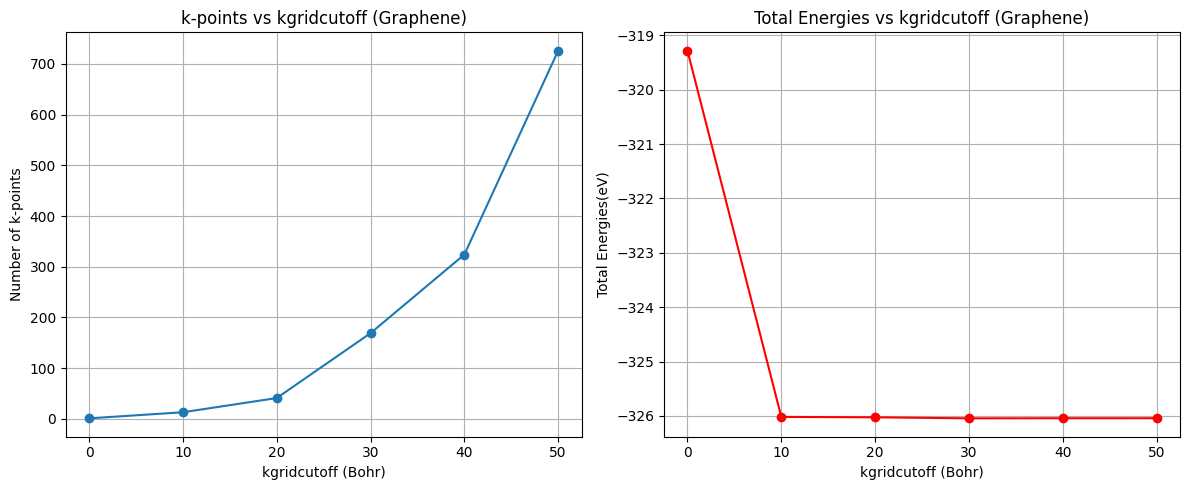

In [43]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("kconv.dat", comments="#")

kcut = data[:,0]
Nk   = data[:,1]
E    = data[:,3]
# plot kgridcutoff vs k-point
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(kcut, Nk, 'o-')
plt.xlabel("kgridcutoff (Bohr)")
plt.ylabel("Number of k-points")
plt.title("k-points vs kgridcutoff (Graphene)")
plt.grid(True)

# plot kgridcutoff vs energy
plt.subplot(1,2,2)
plt.plot(kcut, E, 'o-',color='r')
plt.xlabel("kgridcutoff (Bohr)")
plt.ylabel("Total Energies(eV)")
plt.title("Total Energies vs kgridcutoff (Graphene)")
plt.grid(True)
plt.tight_layout()
plt.show()


At kgridcutoff = 10

- Energy looks converged
- But still borderline

 Slight changes may affect:
- Forces and Band dispersion near Dirac point

At kgridcutoff = 20

- Energy is flat
- Numerical noise minimized
- Safe for geometry optimization and band structure
- 20 is the conservative, reliable choice

The calculation is considered converged at kgridcutoff ≈ 20 Bohr because increasing the k-point density beyond this value changes the total energy by less than the chosen tolerance (≈1 meV per atom), indicating accurate Brillouin zone integration.

# Plot Density of states and Band Structure  at given graphene.fdf

In [106]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX1


In [107]:
%cd /home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [108]:
!mkdir EX2

In [109]:
!cp C.psml graphene.fdf EX2

In [110]:
%cd EX2
!ls

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX2
C.psml	graphene.fdf


In [66]:
!siesta < graphene.fdf > graphene.out

Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed


In [1]:
!cat graphene.fdf

# General system specifications ....
SystemName    graphene
SystemLabel   graphene

NumberOfAtoms    2
NumberOfSpecies  1

%block ChemicalSpeciesLabel
    1   6  C
%endblock ChemicalSpeciesLabel

# Structural parameters...
LatticeConstant 2.476675 Ang
%block LatticeParameters
1.000  1.000  10.0  90.0  90.0  120.0
%endblock LatticeParameters

AtomicCoordinatesFormat fractional

%block AtomicCoordinatesAndAtomicSpecies
  0.33333333  0.66666667  0.5        1     # C
  0.66666667  0.33333333  0.5        1     # C
%endblock AtomicCoordinatesAndAtomicSpecies

# Simulation parameters ...
SolutionMethod         diagon

XC.Functional          LDA
XC.Authors             CA
#Spin                   polarized

SCF.Mixer.Weight       0.1
SCF.Mixer.History      3
SCF.DM.Tolerance       5.0d-5

DM.UseSaveDM           T

# Basis set definition...
PAO.BasisSize         DZP
PAO.EnergyShift       10 meV


# Real space grid...
MeshCutoff           140.0 Ry

#kgridcutoff 0 bohr


# K-sampling (using Monkhor

In [74]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [75]:
%cd /home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX2

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX2


In [76]:
%%bash
Eig2DOS -f -s 0.1 -n 100  -m -12.0 -M 2.0 -k graphene.KP graphene.EIG > dos_100.dat


In [77]:
%%bash
Eig2DOS -f -s 0.1 -n 1000 -m -12.0 -M 2.0 -k graphene.KP graphene.EIG > dos_1000.dat


In [78]:
!cat dos_100.dat


# EIG2DOS: Utility for SIESTA to obtain the electronic density of states
#  E. Artacho, Apr 1999, A. Garcia, Apr 2012
#  Nick R. Papior, Feb 2017
# ------------------------------------------
# Eigenvalues calculated from a non-polarized calculation
# Eigenvalues read from graphene.EIG
# Kpoint weights read from graphene.KP
# Using smearing parameter:   0.1000
# Using 100 points in the energy range
# Selected bands: 1 to: 26
# Emin, Emax in file for selected band(s):    -24.3010111    189.8693500
# Nbands, Nspin, Nk   =     26     1     1
# E_F                 =    -4.3330 eV --> (shifted to ZERO)
# Broadening          =     0.1000 eV
#
#        E            N(up)  (=)   N(down)         Ntot
    -12.000000      0.000000      0.000000      0.000000
    -11.858586      0.000000      0.000000      0.000000
    -11.717172      0.000000      0.000000      0.000000
    -11.575758      0.000000      0.000000      0.000000
    -11.434343      0.000000      0.000000      0.000000
    -11.292929 

In [80]:
%%bash
gnuplot << EOF
set terminal pngcairo size 800,600
set output "dos.png"

set xlabel "Energy (eV)"
set ylabel "Total DOS"
set grid

plot "dos_100.dat"  u 1:4 w l lw 2 title "100 points", \
     "dos_1000.dat" u 1:4 w l lw 2 title "1000 points"

unset output
EOF


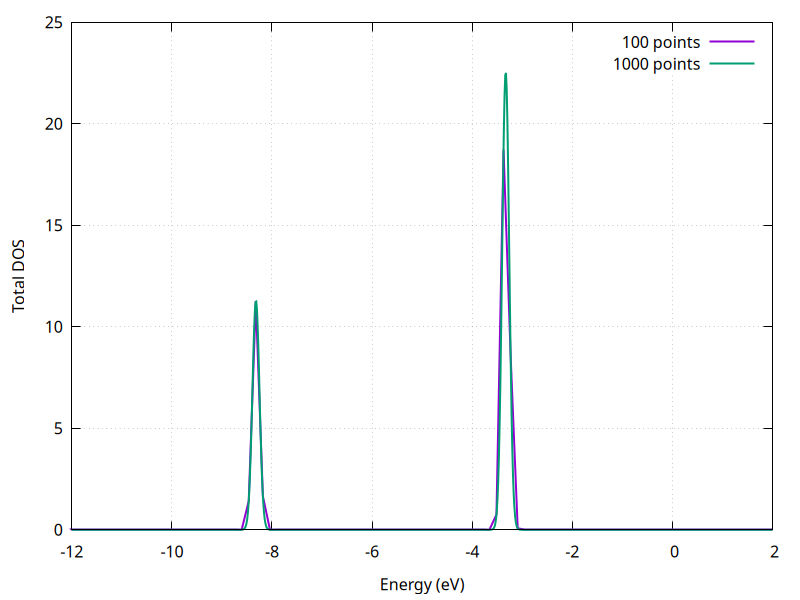

In [86]:
from IPython.display import Image, display
display(Image("dos.png"))


In [64]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX2


In [65]:
ls

0_NORMAL_EXIT          dos.png                      graphene.fdf
BASIS_ENTHALPY         fdf.20260115T102059.281.log  graphene.HSX
BASIS_HARRIS_ENTHALPY  FORCE_STRESS                 graphene.KP
C.ion                  graphene.alloc               graphene.ORB_INDX
C.ion.nc               graphene.BASIS_ENTHALPY      graphene.out
C.ion.xml              graphene.bib                 graphene.STRUCT_OUT
CLOCK                  graphene.BONDS               graphene.XV
C.psml                 graphene.BONDS_FINAL         INPUT_TMP.58579
dos_1000.dat           graphene.DM                  MESSAGES
dos_100.dat            graphene.EIG                 OUTVARS.yml
dos_graphene.png       graphene.FA                  PARALLEL_DIST


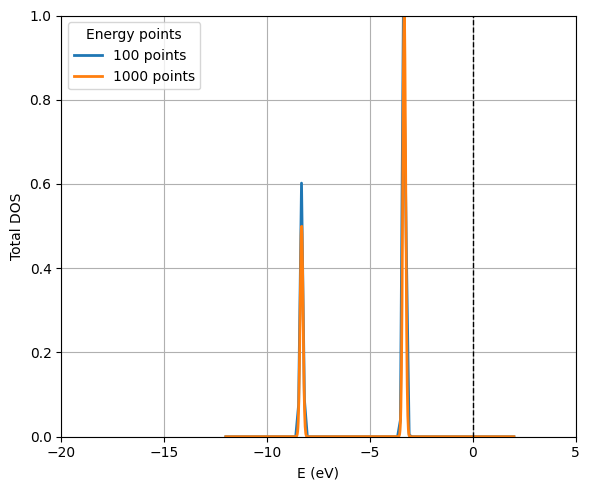

In [89]:
import numpy as np
import matplotlib.pyplot as plt
# load data
dos100  = np.loadtxt("dos_100.dat",  comments="#")
dos1000 = np.loadtxt("dos_1000.dat", comments="#")

E100,  DOS100  = dos100[:,0],  dos100[:,3]
E1000, DOS1000 = dos1000[:,0], dos1000[:,3]
DOS100_norm  = DOS100  / DOS100.max()
DOS1000_norm = DOS1000 / DOS1000.max()
plt.figure(figsize=(6,5))

plt.plot(E100,  DOS100_norm,  label="100 points",  lw=2)
plt.plot(E1000, DOS1000_norm, label="1000 points", lw=2)

# Dirac point (Fermi level)
plt.axvline(0, color="k", linestyle="--", lw=1)

plt.xlim(-20, 5)
plt.ylim(0, 1)
plt.xlabel("E (eV)")
plt.ylabel("Total DOS")
plt.legend(title="Energy points")
plt.grid(True)

plt.tight_layout()
plt.show()


# For band structure

In [90]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [91]:
%cd EX2

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX2


In [92]:
ls

0_NORMAL_EXIT          fdf.20260115T102059.281.log  graphene.HSX
BASIS_ENTHALPY         fdf.20260115T113711.704.log  graphene.KP
BASIS_HARRIS_ENTHALPY  FORCE_STRESS                 graphene.ORB_INDX
C.ion                  graphene.alloc               graphene.out
C.ion.nc               graphene.BASIS_ENTHALPY      graphene.STRUCT_OUT
C.ion.xml              graphene.bib                 graphene.XV
CLOCK                  graphene.BONDS               INPUT_TMP.31001
C.psml                 graphene.BONDS_FINAL         INPUT_TMP.58579
dos_1000.dat           graphene.DM                  MESSAGES
dos_100.dat            graphene.EIG                 OUTVARS.yml
dos_graphene.png       graphene.FA                  PARALLEL_DIST
dos.png                graphene.fdf


In [93]:
!siesta < graphene.fdf > graphene.out

Gamma-point calculation with interaction between periodic images
Some features might not work optimally:
e.g. DM initialization from atomic data
Job completed


In [123]:
ls

0_NORMAL_EXIT                FORCE_STRESS             graphene.KP
BASIS_ENTHALPY               graphene.alloc           graphene.ORB_INDX
BASIS_HARRIS_ENTHALPY        graphene.bands           graphene.out
C.ion                        graphene.BASIS_ENTHALPY  graphene.STRUCT_OUT
C.ion.nc                     graphene.bib             graphene.XV
C.ion.xml                    graphene.BONDS           INPUT_TMP.36269
CLOCK                        graphene.BONDS_FINAL     MESSAGES
C.psml                       graphene.DM              NON_TRIMMED_KP_LIST
dos_1000.dat                 graphene.EIG             OUTVARS.yml
dos_100.dat                  graphene.FA              PARALLEL_DIST
dos.png                      graphene.fdf
fdf.20260115T115856.971.log  graphene.HSX


In [124]:
!cat graphene.bands

  -5.1933984891251272     
   0.0000000000000000        2.1175814565278825     
  -24.410012051156805        189.53853716112170     
          26           1         106
  0.000000    -19.2429    -18.2156    -11.4267     -7.3161     -3.3263      2.3312      8.7113      9.0939      9.1207     10.7346
               14.7614     18.5015     19.2054     27.2345     32.4830     34.9107     35.8564     41.5184     45.9105     47.9585
               56.4360     66.1983     66.6323     71.5261     89.7606    111.3359
  0.025836    -19.3543    -18.0943    -11.4205     -7.3586     -3.2734      2.3346      8.4136      9.0275      9.3588     10.8508
               14.7136     18.5072     19.2171     27.2833     32.4415     34.9522     35.4511     42.0479     45.9868     47.9078
               56.5045     66.2496     66.5444     71.5209     89.7517    111.2887
  0.051673    -19.6014    -17.8176    -11.4019     -7.4797     -3.1215      2.3448      7.9586      8.8006      9.7169     11.1473
         

In [125]:
ls graphene.bands

graphene.bands


In [126]:
!gnubands -G -F -o graph -E 10 -e -20 graphene.bands
!ls graph.*
!gnuplot --persist graph.gplot

graph.gplot


In [127]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX2


In [129]:
!Eig2DOS -f -s 0.1 -n 400 -m -12.0 -M 2.0 -k graphene.KP  graphene.EIG > dos

In [131]:
%%bash
gnuplot
plot "dos" u 1:4 with lines

In [132]:
!head dos


# EIG2DOS: Utility for SIESTA to obtain the electronic density of states
#  E. Artacho, Apr 1999, A. Garcia, Apr 2012
#  Nick R. Papior, Feb 2017
# ------------------------------------------
# Eigenvalues calculated from a non-polarized calculation
# Eigenvalues read from graphene.EIG
# Kpoint weights read from graphene.KP
# Using smearing parameter:   0.1000
# Using 400 points in the energy range
# Selected bands: 1 to: 26


In [133]:
%%bash
gnuplot << EOF
set terminal qt
set xlabel "Energy (eV)"
set ylabel "Total DOS"
set grid
plot "dos" u 1:4 w l lw 2 title "Graphene DOS"
pause -1
EOF


In [134]:
%%bash
gnuplot << EOF
set terminal pngcairo size 800,600
set output "dos.png"

set xlabel "Energy (eV)"
set ylabel "Total DOS"
set grid
plot "dos" u 1:4 w l lw 2 title "Graphene DOS"

unset output
EOF


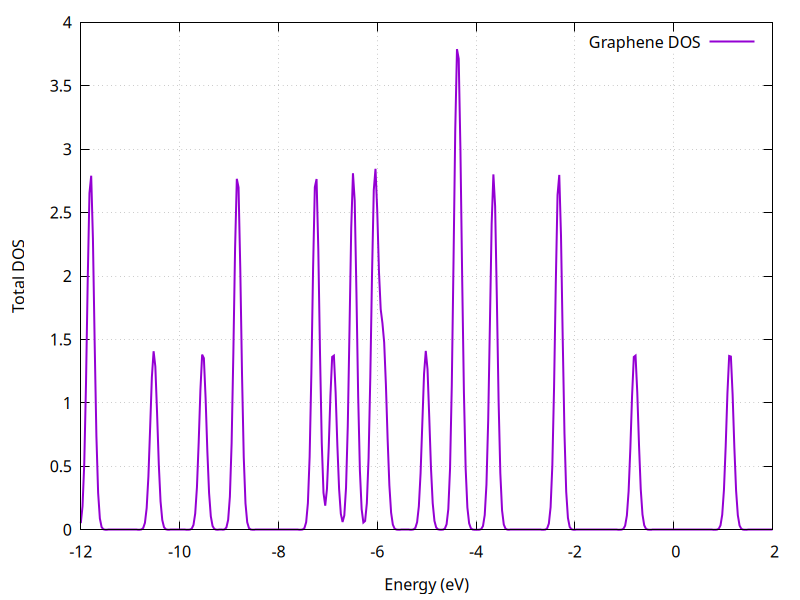

In [135]:
from IPython.display import Image, display
display(Image("dos.png"))


In [136]:
ls

0_NORMAL_EXIT          fdf.20260115T115856.971.log  graphene.HSX
bandstructure.pdf      FORCE_STRESS                 graphene.KP
BASIS_ENTHALPY         graph                        graphene.ORB_INDX
BASIS_HARRIS_ENTHALPY  graphene.alloc               graphene.out
C.ion                  graphene.bands               graphene.STRUCT_OUT
C.ion.nc               graphene.BASIS_ENTHALPY      graphene.XV
C.ion.xml              graphene.bib                 graph.gplot
CLOCK                  graphene.BONDS               INPUT_TMP.36269
C.psml                 graphene.BONDS_FINAL         MESSAGES
dos                    graphene.DM                  NON_TRIMMED_KP_LIST
dos_1000.dat           graphene.EIG                 OUTVARS.yml
dos_100.dat            graphene.FA                  PARALLEL_DIST
dos.png                graphene.fdf


## Ploting band structure at different grapheneKP.file

In [11]:
!mkdir EX3

In [12]:
!cp C.psml graphene.fdf EX3/

In [13]:
%cd EX3

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX3/EX3


In [14]:
cp graphene.fdf graphene_template.fdf


In [15]:
ls graphene_template.fdf

graphene_template.fdf


In [16]:
!cat graphene_template.fdf

# General system specifications ....
SystemName    graphene
SystemLabel   graphene

NumberOfAtoms    2
NumberOfSpecies  1

%block ChemicalSpeciesLabel
    1   6  C
%endblock ChemicalSpeciesLabel

# Structural parameters...
LatticeConstant 2.476675 Ang
%block LatticeParameters
1.000  1.000  10.0  90.0  90.0  120.0
%endblock LatticeParameters

AtomicCoordinatesFormat fractional

%block AtomicCoordinatesAndAtomicSpecies
  0.33333333  0.66666667  0.5        1     # C
  0.66666667  0.33333333  0.5        1     # C
%endblock AtomicCoordinatesAndAtomicSpecies

# Simulation parameters ...
SolutionMethod         diagon

XC.Functional          LDA
XC.Authors             CA
#Spin                   polarized

SCF.Mixer.Weight       0.1
SCF.Mixer.History      3
SCF.DM.Tolerance       5.0d-5

DM.UseSaveDM           T

# Basis set definition...
PAO.BasisSize         DZP
PAO.EnergyShift       10 meV


# Real space grid...
MeshCutoff           140.0 Ry

#kgridcutoff 0 bohr


# K-sampling (using Monkhor

In [17]:
%%bash

for Y in 1 2 3 4
do
    dir="KGRID_${Y}"
    mkdir -p $dir

    # Replace YVAL by actual number
    sed "s/YVAL/$Y/g" graphene_template.fdf > $dir/graphene.fdf

    # Copy pseudopotential
    cp C.psml $dir/

    echo "Running k-grid ${Y}x${Y}x1"

    cd $dir
    siesta < graphene.fdf > graphene.out
    cd ..
done


Running k-grid 1x1x1


Job completed


Running k-grid 2x2x1


Job completed


Running k-grid 3x3x1


Job completed


Running k-grid 4x4x1


Job completed


In [181]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX3


In [182]:
ls

1graphene.bands  4graphene.bands  graphene.fdf           KGRID_2/
2graphene.bands  C.psml           graphene_template.fdf  KGRID_3/
3graphene.bands  graph            KGRID_1/               KGRID_4/


In [175]:
ls KGRID_1

0_NORMAL_EXIT                graphene.alloc           graphene.KP
BASIS_ENTHALPY               graphene.bands           graphene.ORB_INDX
BASIS_HARRIS_ENTHALPY        graphene.BASIS_ENTHALPY  graphene.out
C.ion                        graphene.bib             graphene.STRUCT_OUT
C.ion.nc                     graphene.BONDS           graphene.XV
C.ion.xml                    graphene.BONDS_FINAL     INPUT_TMP.18589
CLOCK                        graphene.DM              INPUT_TMP.31309
C.psml                       graphene.EIG             MESSAGES
fdf.20260115T124212.011.log  graphene.FA              NON_TRIMMED_KP_LIST
fdf.20260115T130019.291.log  graphene.fdf             OUTVARS.yml
FORCE_STRESS                 graphene.HSX             PARALLEL_DIST


In [183]:
ls *.bands

1graphene.bands  2graphene.bands  3graphene.bands  4graphene.bands


In [184]:
!gnubands -F -G -o bandstructure -E 10 -e -20 1graphene.bands

In [230]:
!gnubands -F -G -o bandstructure -E 10 -e -20 2graphene.bands
!gnubands -F -G -o bandstructure -E 10 -e -20 3graphene.bands
!gnubands -F -G -o bandstructure -E 10 -e -20 4graphene.bands

In [231]:
!gnuplot --persist -e "set grid" bandstructure.gplot

In [185]:

!gnuplot --persist -e "set grid" bandstructure.gplot

In [167]:
!cat KGRID_1.fdf


cat: KGRID_1.fdf: No such file or directory


In [179]:
!cat graphene_template.fdf

# General system specifications ....
SystemName    graphene
SystemLabel   graphene

NumberOfAtoms    2
NumberOfSpecies  1

%block ChemicalSpeciesLabel
    1   6  C
%endblock ChemicalSpeciesLabel

# Structural parameters...
LatticeConstant 2.476675 Ang
%block LatticeParameters
1.000  1.000  10.0  90.0  90.0  120.0
%endblock LatticeParameters

AtomicCoordinatesFormat fractional

%block AtomicCoordinatesAndAtomicSpecies
  0.33333333  0.66666667  0.5        1     # C
  0.66666667  0.33333333  0.5        1     # C
%endblock AtomicCoordinatesAndAtomicSpecies

# Simulation parameters ...
SolutionMethod         diagon

XC.Functional          LDA
XC.Authors             CA
#Spin                   polarized

SCF.Mixer.Weight       0.1
SCF.Mixer.History      3
SCF.DM.Tolerance       5.0d-5

DM.UseSaveDM           T

# Basis set definition...
PAO.BasisSize         DZP
PAO.EnergyShift       10 meV


# Real space grid...
MeshCutoff           140.0 Ry

#kgridcutoff 0 bohr


# K-sampling (using Monkhor

In [191]:
!gnubands -G -F -o 1graphene.dat -E 10 -e -20 1graphene.bands
!gnubands -G -F -o 2graphene.dat -E 10 -e -20 2graphene.bands
!gnubands -G -F -o 3graphene.dat -E 10 -e -20 3graphene.bands
!gnubands -G -F -o 4graphene.dat -E 10 -e -20 4graphene.bands

In [221]:
%%bash
cat > bands_multiplot.gp << 'EOF'
set terminal pngcairo size 900,900
set output "graphene_bands_compare.png"

set multiplot layout 2,2 title "Exercise 1: Graphene Band Structure"

set yrange [-20:10]
set ylabel "Energy (eV)"
set grid
set xtics ("Γ" 0, "K" 1, "M" 2, "Γ" 3)
set arrow from graph 0, first 0 to graph 1, first 0 nohead dt 2 lc rgb "black"

# ---- Panel 1: k-grid 1 1 1 ----
set title "Y=1"
plot "1graphene.dat" using 1:2 w l lw 2 lc rgb "purple" notitle

# ---- Panel 2: k-grid 2 2 1 ----
set title "Y=2"
unset ylabel
plot "2graphene.dat" using 1:2 w l lw 2 lc rgb "purple" notitle

# ---- Panel 3: k-grid 3 3 1 ----
set title "Y=3"
plot "3graphene.dat" using 1:2 w l lw 2 lc rgb "purple" notitle

# ---- Panel 4: k-grid 4 4 1 ----
set title "Y=4"
plot "4graphene.dat" using 1:2 w l lw 2 lc rgb "purple" notitle

unset multiplot
EOF

In [222]:
!gnuplot bands_multiplot.gp

In [223]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX3


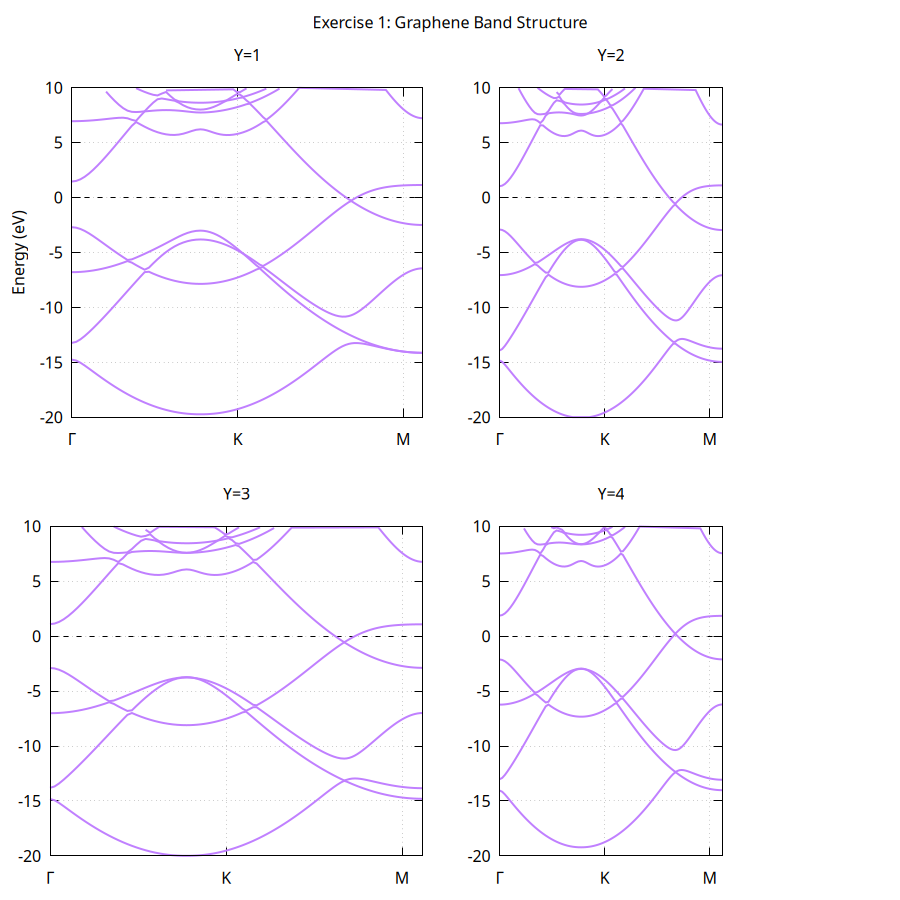

In [224]:
from IPython.display import Image
Image("graphene_bands_compare.png")

In [241]:
%%bash
cat > bands_multiplot.gp << 'EOF'
set terminal pngcairo size 1200,900
set output "graphene_bands_compare.png"

set multiplot layout 2,2 margins 0.08,0.98,0.08,0.95 spacing 0.06,0.06
set grid
set yrange [-20:10]
set ylabel "E - E_F (eV)"
set style line 1 lc rgb "magenta" lw 1.5

# Vertical line at K
set arrow from 2, -20 to 2, 10 nohead dt 2 lc rgb "black"

# Fermi level
set arrow from graph 0, 0 to graph 1, 0 nohead dt 2 lc rgb "black"

# -------- Y = 1 --------
set title "Y = 1"
set xtics ("M" 0, "Γ" 1, "K" 2, "M" 3)
plot for [i=2:*] "1graphene.dat" using 1:i w l ls 1 notitle

# -------- Y = 2 --------
set title "Y = 2"
unset ylabel
plot for [i=2:*] "2graphene.dat" using 1:i w l ls 1 notitle

# -------- Y = 3 --------
set title "Y = 3"
set ylabel "E - E_F (eV)"
plot for [i=2:*] "3graphene.dat" using 1:i w l ls 1 notitle

# -------- Y = 4 --------
set title "Y = 4"
unset ylabel
plot for [i=2:*] "4graphene.dat" using 1:i w l ls 1 notitle

unset multiplot
EOF


In [242]:
%%bash
gnuplot bands_multiplot.gp


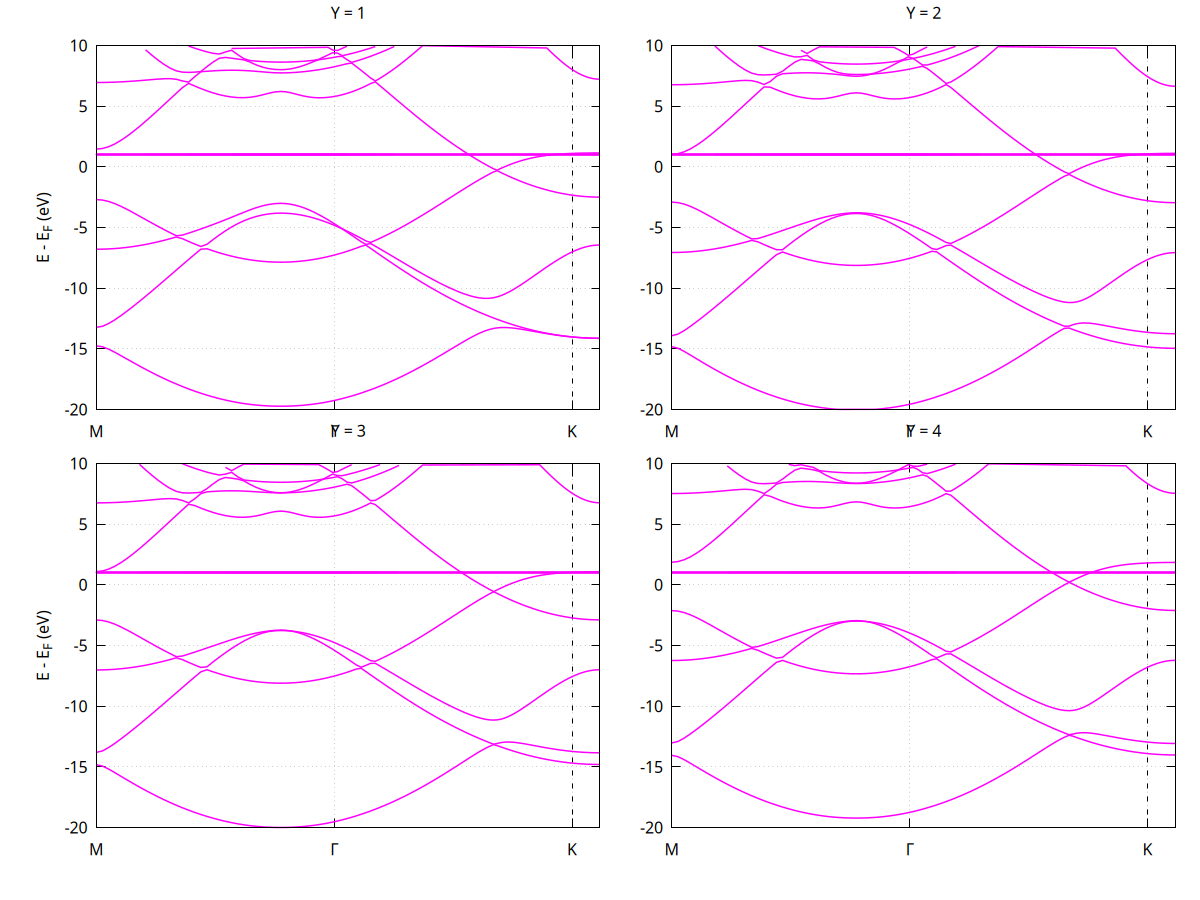

In [243]:
from IPython.display import Image
Image("graphene_bands_compare.png")

In [247]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX3


In [248]:
ls *.bands

1graphene.bands  2graphene.bands  3graphene.bands  4graphene.bands


In [249]:
!gnubands -F -G -o bandstructure -E 10 -e -20 1graphene.bands


In [251]:
!gnuplot --persist -e "set grid" bandstructure.gplot

In [252]:
!gnubands -F -G -o bandstructure -E 10 -e -20 2graphene.bands


In [253]:
!gnuplot --persist -e "set grid" bandstructure.gplot

In [254]:
!gnubands -F -G -o bandstructure -E 10 -e -20 3graphene.bands
!gnuplot --persist -e "set grid" bandstructure.gplot

In [4]:
!gnubands -F -G -o bandstructure -E 10 -e -20 4graphene.bands
!gnuplot --persist -e "set grid" bandstructure.gplot

In [2]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene


In [3]:
%cd EX3

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX3


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
!cat garphene.fdf

cat: garphene.fdf: No such file or directory


In [6]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene


In [8]:
!cat graphene.fdf

# General system specifications ....
SystemName    graphene
SystemLabel   graphene

NumberOfAtoms    2
NumberOfSpecies  1

%block ChemicalSpeciesLabel
    1   6  C
%endblock ChemicalSpeciesLabel

# Structural parameters...
LatticeConstant 2.476675 Ang
%block LatticeParameters
1.000  1.000  10.0  90.0  90.0  120.0
%endblock LatticeParameters

AtomicCoordinatesFormat fractional

%block AtomicCoordinatesAndAtomicSpecies
  0.33333333  0.66666667  0.5        1     # C
  0.66666667  0.33333333  0.5        1     # C
%endblock AtomicCoordinatesAndAtomicSpecies

# Simulation parameters ...
SolutionMethod         diagon

XC.Functional          LDA
XC.Authors             CA
#Spin                   polarized

SCF.Mixer.Weight       0.1
SCF.Mixer.History      3
SCF.DM.Tolerance       5.0d-5

DM.UseSaveDM           T

# Basis set definition...
PAO.BasisSize         DZP
PAO.EnergyShift       10 meV


# Real space grid...
MeshCutoff           140.0 Ry

#kgridcutoff 0 bohr


# K-sampling (using Monkhor

In [10]:
%cd EX3
!cat graphene_template.fdf

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX3
# General system specifications ....
SystemName    graphene
SystemLabel   graphene

NumberOfAtoms    2
NumberOfSpecies  1

%block ChemicalSpeciesLabel
    1   6  C
%endblock ChemicalSpeciesLabel

# Structural parameters...
LatticeConstant 2.476675 Ang
%block LatticeParameters
1.000  1.000  10.0  90.0  90.0  120.0
%endblock LatticeParameters

AtomicCoordinatesFormat fractional

%block AtomicCoordinatesAndAtomicSpecies
  0.33333333  0.66666667  0.5        1     # C
  0.66666667  0.33333333  0.5        1     # C
%endblock AtomicCoordinatesAndAtomicSpecies

# Simulation parameters ...
SolutionMethod         diagon

XC.Functional          LDA
XC.Authors             CA
#Spin                   polarized

SCF.Mixer.Weight       0.1
SCF.Mixer.History      3
SCF.DM.Tolerance       5.0d-5

DM.UseSaveDM           T

# Basis set definition...
PAO.BasisSize         DZP
PAO.EnergyShift       10 meV


# Real spa

# EXERCISE 4 // PLOTING BAND STRUCTURE 

In [19]:
%cd ..

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene


In [20]:
!mkdir EX4

In [21]:
!cp C.psml graphene.fdf EX4/

In [23]:
%cd EX4

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX4


In [61]:
!cp  graphene.fdf graphene_template.fdf

In [62]:
ls graphene_template.fdf

graphene_template.fdf


In [63]:
!cat graphene_template.fdf

# General system specifications ....
SystemName    graphene
SystemLabel   graphene

NumberOfAtoms    2
NumberOfSpecies  1

%block ChemicalSpeciesLabel
    1   6  C
%endblock ChemicalSpeciesLabel

# Structural parameters...
LatticeConstant 2.476675 Ang
%block LatticeParameters
1.000  1.000  10.0  90.0  90.0  120.0
%endblock LatticeParameters

AtomicCoordinatesFormat fractional

%block AtomicCoordinatesAndAtomicSpecies
  0.33333333  0.66666667  0.5        1     # C
  0.66666667  0.33333333  0.5        1     # C
%endblock AtomicCoordinatesAndAtomicSpecies

# Simulation parameters ...
SolutionMethod         diagon

XC.Functional          LDA
XC.Authors             CA
#Spin                   polarized

SCF.Mixer.Weight       0.1
SCF.Mixer.History      3
SCF.DM.Tolerance       5.0d-5

DM.UseSaveDM           T

# Basis set definition...
PAO.BasisSize         DZP
PAO.EnergyShift       10 meV


# Real space grid...
MeshCutoff           140.0 Ry

#kgridcutoff 0 bohr


# K-sampling (using Monkhor

In [64]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX4


In [65]:
ls

C.psml  graphene.fdf  graphene_template.fdf


In [66]:
ls

C.psml  graphene.fdf  graphene_template.fdf


In [69]:
%%bash

for Y in 1 2 3 4 6 8 12 16 24
do
    dir="KGRID_${Y}"
    mkdir -p $dir

    # Replace YVAL by actual number
    sed "s/YVAL/$Y/g" graphene_template.fdf > $dir/graphene.fdf

    # Copy pseudopotential
    cp C.psml $dir/

    echo "Running k-grid ${Y}x${Y}x1"

    cd $dir
    siesta < graphene.fdf > graphene.out
    grep "SCF Cycle Covered" graphene.out
    cd ..
done


Running k-grid 1x1x1


Job completed


Running k-grid 2x2x1


Job completed


Running k-grid 3x3x1


...

Job completed


Running k-grid 16x16x1


Job completed


Running k-grid 24x24x1


Job completed


In [70]:
ls

C.psml        graphene_template.fdf  KGRID_12/  KGRID_2/   KGRID_3/  KGRID_6/
graphene.fdf  KGRID_1/               KGRID_16/  KGRID_24/  KGRID_4/  KGRID_8/


In [90]:
%%bash

echo "# kgridcutoff  Nkpoints  keff(Ang^-1)  TotalEnergy(eV)" > kconv.dat

for d in $(ls -d KGRID_* | sort -t_ -k2 -n); do
    kcut=${d#KGRID_}

    Nk=$(grep "Number of k-points" "$d/graphene.out" | awk '{print $NF}')

    keff=$(grep -i "k-cutoff (effective)" "$d/graphene.out" | awk '{print $(NF-1)}')
    keff=${keff:-0.0}

    E=$(grep -i " Total =" "$d/graphene.out" | tail -1 | awk '{print $4}')

    printf "%-12s %-10s %-12s %-15s\n" "$kcut" "$Nk" "$keff" "$E" >> kconv.dat
done


In [91]:
!cat kconv.dat

# kgridcutoff  Nkpoints  keff(Ang^-1)  TotalEnergy(eV)
1            1          1.238        -325.262854    
2            2          2.477        -326.763673    
3            6          3.715        -326.153682    
4            8          4.953        -326.030649    
6            18         7.430        -326.052729    
8            32         9.907        -326.045167    
12           72         12.383       -326.044830    
16           128        12.383       -326.043398    
24           288        12.383       -326.043794    


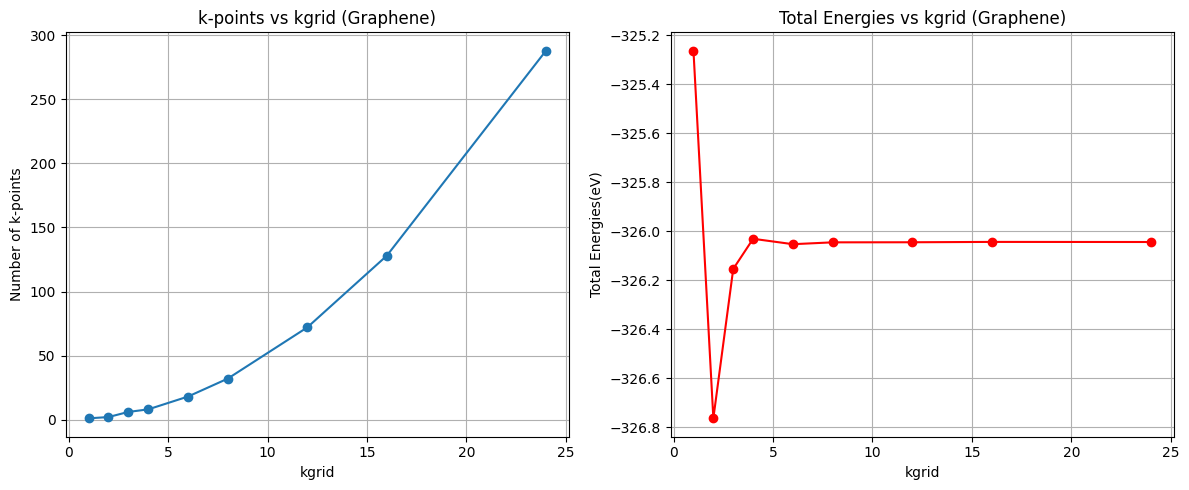

In [92]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("kconv.dat", comments="#")

kcut = data[:,0]
Nk   = data[:,1]
E    = data[:,3]
# plot kgridcutoff vs k-point
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(kcut, Nk, 'o-')
plt.xlabel("kgrid")
plt.ylabel("Number of k-points")
plt.title("k-points vs kgrid (Graphene)")
plt.grid(True)

# plot kgridcutoff vs energy
plt.subplot(1,2,2)
plt.plot(kcut, E, 'o-',color='r')
plt.xlabel("kgrid")
plt.ylabel("Total Energies(eV)")
plt.title("Total Energies vs kgrid (Graphene)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [93]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX4


In [94]:
!siesta < graphene.fdf > graphene.out

Job completed


In [100]:
%%bash
Eig2DOS -f -s 0.2 -n 400  -m -12.0 -M 2.0 -k graphene.KP graphene.EIG > dos

In [109]:
%%bash
gnuplot << EOF
set terminal pdfcairo
set output "dos.pdf"

set xlabel "Energy (eV)"
set ylabel "DOS (states/eV)"
set grid
plot "dos" u 1:4 w l lw 2 title "Graphene DOS"

set output
EOF


In [110]:
ls

0_NORMAL_EXIT                graphene.BONDS         kconv_raw.dat
BASIS_ENTHALPY               graphene.BONDS_FINAL   kconv_table.dat
BASIS_HARRIS_ENTHALPY        graphene.DM            KGRID_1/
C.ion                        graphene.EIG           KGRID_12/
C.ion.nc                     graphene.FA            KGRID_16/
C.ion.xml                    graphene.fdf           KGRID_2/
CLOCK                        graphene.HSX           KGRID_24/
C.psml                       graphene.KP            KGRID_3/
dos                          graphene.ORB_INDX      KGRID_4/
dos.pdf                      graphene.out           KGRID_6/
fdf.20260115T174402.109.log  graphene.STRUCT_OUT    KGRID_8/
FORCE_STRESS                 graphene_template.fdf  kpoint_convergence.pdf
graphene.alloc               graphene.XV            MESSAGES
graphene.bands               INPUT_TMP.43390        NON_TRIMMED_KP_LIST
graphene.BASIS_ENTHALPY      kconv.dat              OUTVARS.yml
graphene.bib                 kconv.gnu    

In [111]:
!gnubands -F -G -o bandstructure -E 10 -e -20 *.bands

In [121]:
ls *.bands

graphene1.bands  graphene3.bands  graphene.bands
graphene2.bands  graphene4.bands


In [122]:
!gnuplot --persist -e "set grid" bandstructure.gplot

In [ ]:
!siesta < graphene.fdf > graphene.out

In [139]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/kpoint-convergence/01-Graphene/EX4


In [140]:
!gnubands -F -G -o bandstructure -E 10 -e -20 graphene1.bands
!gnubands -F -G -o bandstructure -E 10 -e -20 graphene2.bands
!gnubands -F -G -o bandstructure -E 10 -e -20 graphene3.bands
!gnubands -F -G -o bandstructure -E 10 -e -20 graphene4.bands

In [141]:
%%bash
cat > bands_multiplot.gp << 'EOF'
set terminal pngcairo size 900,1200
set output "graphene_bands_compare.png"

set multiplot layout 2,2 title "Exercise 1: Graphene Band Structure"

set yrange [-20:10]
set ylabel "Energy (eV)"
set grid
set xtics ("Γ" 0, "K" 1, "M" 2, "Γ" 3)
set arrow from graph 0, first 0 to graph 1, first 0 nohead dt 2 lc rgb "black"

# ---- Panel 1: k-grid 1 1 1 ----
set multiplot layout 2,2 title "Band structure vs k-grid"

# Panel 1
set title "KGRID_1"
set ylabel "Energy (eV)"
plot "graphene1.bands" u 1:2 w l lw 1 lc rgb "purple" notitle

# Panel 2
set title "KGRID_2"
unset ylabel
plot "graphene2.bands" u 1:2 w l lw 1 lc rgb "purple" notitle

# Panel 3
set title "KGRID_3"
plot "graphene3.bands" u 1:2 w l lw 1 lc rgb "purple" notitle

# Panel 4
set title "KGRID_4"
plot "graphene4.bands" u 1:2 w l lw 1 lc rgb "purple" notitle

unset multiplot

unset multiplot
EOF

In [142]:
!gnuplot bands_multiplot.gp

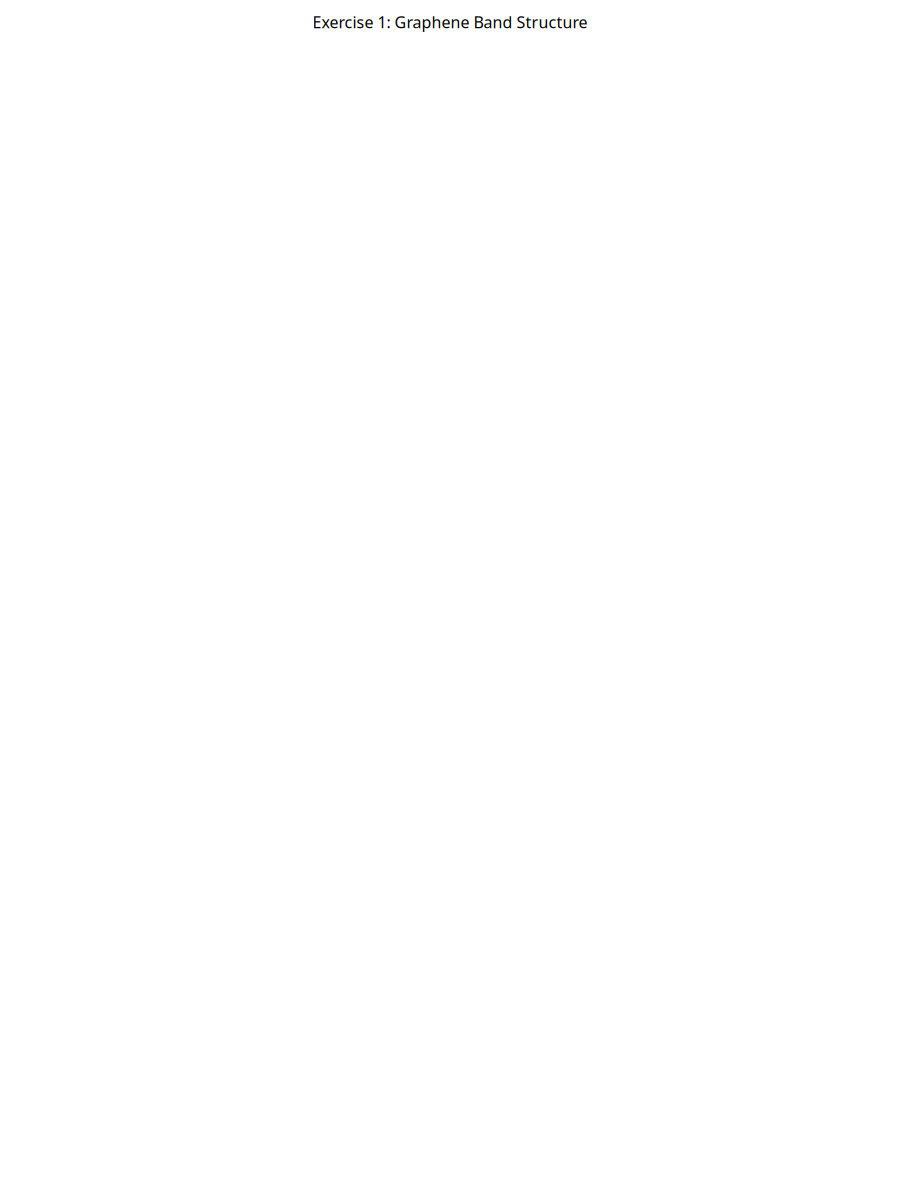

In [143]:
from IPython.display import Image
Image("graphene_bands_compare.png")